In [1]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import scipy.optimize as curve_fit

In [3]:
current_directory = Path.cwd().parent
compiled_file_name = Path.joinpath(current_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(current_directory, "points_of_interest.json")
RC_values_file_name = Path.joinpath(current_directory, "RC_values.csv")
ocv_soc_dict_file_name = Path.joinpath(current_directory, "ocv_soc_dict.json")

In [4]:
points_of_interest = json.load(open(points_of_interest_file_name, 'r'))

In [5]:
compiled_df = pd.read_csv(compiled_file_name)

In [8]:
before_open = points_of_interest['before_open']
before_close = points_of_interest['before_close']

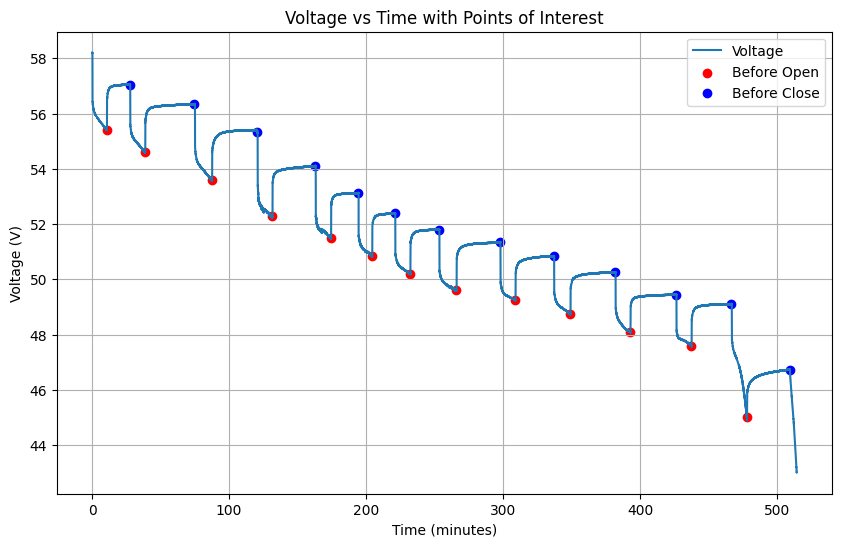

In [11]:

plt.figure(figsize=(10, 6))
plt.plot(compiled_df['Translated Time (minutes)'], compiled_df['Calibrated Voltage'], label='Voltage')
plt.scatter(before_open['time'], before_open['voltage'], color='red', label='Before Open')
plt.scatter(before_close['time'], before_close['voltage'], color='blue', label='Before Close')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time with Points of Interest')
plt.legend()
plt.grid()
plt.show()

In [10]:
if before_close['time'][0] < before_open['time'][0]:
    before_close['time'] = before_close['time'][1:]
    before_close['voltage'] = before_close['voltage'][1:]
    before_close['index'] = before_close['index'][1:]
    print("Dropped first point from before_close.")

Dropped first point from before_close.
